# **Procesos de Markov. Ejercicios para practicar.**

## 1. Urnas de Polya ## 

En el modelo de Ehrenfest que trabajamos en la sesión de clase, hemos considerado bolas que están contenidas en un par de contenedores (o urnas) y pueden pasar de uno a otro.

Otro modelo famoso es el de las llamadas **Urnas de Polya**. En él hay una única urna con bolas de dos colores (digamos blancas y negras), cuyo número va cambiando de forma aleatoria según ciertas reglas. 
Podemos estudiar dos modelos.

**Urna de Polya fuerte**: En cada paso, elegimos aleatoriamente una de las bolas contenidas en la urna. *Si la bola elegida es de un cierto color, la devolvemos a la urna y añadimos otras (en número fijo $r$ de ellas)* **del mismo color que la elegida**.

**Urna de Polya débil**: En cada paso, elegimos aleatoriamente una de las bolas contenidas en la urna. *Si la bola elegida es de un cierto color, la devolvemos a la urna junto a otras (en número fijo $r$ de ellas)* **de color distinto al de la elegida**.

Lo habitual es empezar con $b=1$ bola blanca y $n=1$ bola negra y que tras cada extracción se meta en la urna $r=1$ bola adicional (del color que toque), pero nosotros, para experimentar mejor, vamos a escribir programas con estos datos $(b,n,r)$ como parámetros.

*Nota*: En <a href="https://dayinlab.com/2017/09/05/la-urna-de-polya-por-que-la-gente-bebe-coca-cola/" target="_blank"> esta página de divulgación </a> hay una explicación sencilla e interesante sobre el tipo de situaciones a las que aplica el modelo de urna fuerte de Polya.



**URNA FUERTE**

**a)** Escribe un programa que, dados el número inicial de bolas blancas y negras, la cantidad de bolas añadidas tras cada extracción, y el número de extracciones sucesivas que hacemos, nos devuelva un gráfico con la proporción de bolas blancas **tras cada extracción** en un color, y la proporción de bolas blancas **tras cada extracción** en otro color.

¿Qué esperarás que pase? ¿Que se imponga uno de los dos colores? ¿Que las proporciones oscilen caóticamente? ¿Que las proporciones se estabilicen de algún modo?

Repite **unas cuantas veces** el experimento empezando con $1$ bola blanca y $1$ negra, añadiendo $1$ bola cada vez y realizando $1000$ extracciones, observa los resultados y comprueba si se confirma tu intuición.

In [1]:
def polya_fuerte(b, n, r, extracciones):
    propb=[(0,b/(b+n))]
    propn=[(0,n/(b+n))]
    for k in xsrange(extracciones):
        if random()<b/(b+n):
            b+=r
        else:
            n+=r
        propb.append((k+1, b/(b+n)))
        propn.append((k+1, n/(b+n)))
    return points(propb, color='cyan')+points(propn, color='black')

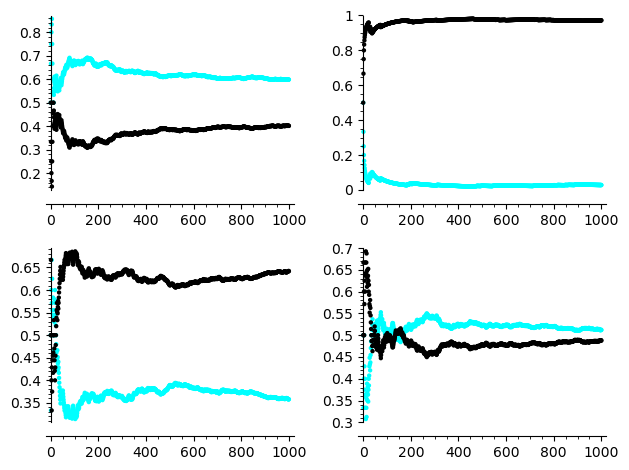

In [2]:
#ejecutamos cuatro veces y vemos los resultados juntos con el comando graphics_array
g1=polya_fuerte(1, 1, 1, 1000)
g2=polya_fuerte(1, 1, 1, 1000)
g3=polya_fuerte(1, 1, 1, 1000)
g4=polya_fuerte(1, 1, 1, 1000)

    
graphics_array(((g1,g2),(g3,g4)))

In [3]:
#Parece que siempre se llega a una situación de equilibrio... ¡pero el equilibrio es diferente cada vez!

**b)** Para ver cuáles son los resultados posibles, crea un diccionario que tenga como claves 
los números finales de blancas en $1000$ repeticiones del experimento anterior, y como valores la fecuencia con la que se da ese resultado. Representa gráficamente los puntos del diccionario. ¿Qué distribución obtienes?

**NOTA**: te puede interesar modificar ligeramente el programa anterior para que, en lugar del gráfico, te dé el número de bolas blancas.

In [4]:
def polya_fuerte2(b, n, r, extracciones):
    propb=[(0,b/(b+n))]
    propn=[(0,n/(b+n))]
    for k in xsrange(extracciones):
        if random()<b/(b+n):
            b+=r
        else:
            n+=r
    return b

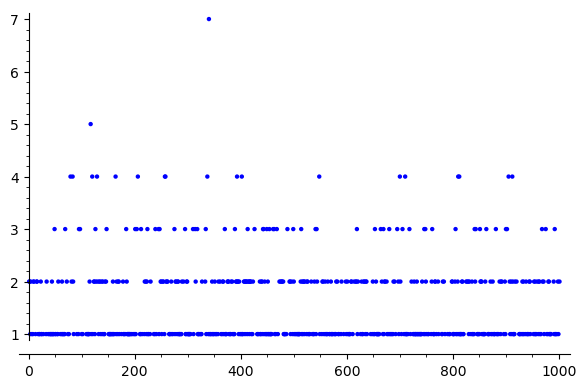

In [11]:

repeticiones=1000
extracciones=1000
r=1
dic=dict()
for _ in xsrange(repeticiones):
    nuevo=polya_fuerte2(1, 1, r, extracciones)
    if nuevo in dic:
        dic[nuevo]+=1
    else:
        dic[nuevo]=1

points(dic.items()) 

In [6]:
#Parece que el estado final puede ser cualquiera de los posibles sin preferencias por unos sobre otros

**URNA DÉBIL**

**c)** Repite el apartado a) para la Urna de Polya débil.

¿Qué observas ahora?

In [9]:
def polya_debil(b, n, r, extracciones):
    propb=[(0,b/(b+n))]
    propn=[(0,n/(b+n))]
    for k in xsrange(extracciones):
        if random()<b/(b+n):
            n+=r
        else:
            b+=r
        propb.append((k+1, b/(b+n)))
        propn.append((k+1, n/(b+n)))
    return points(propb, color='cyan')+points(propn, color='black')


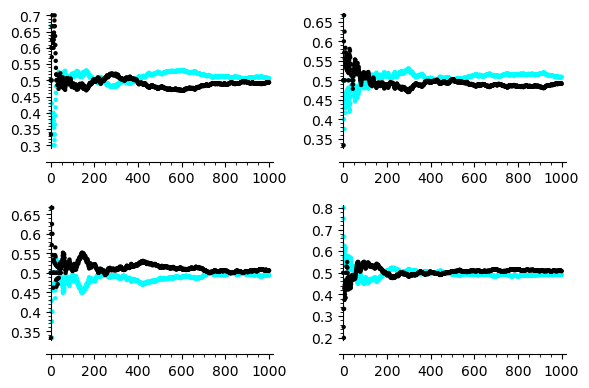

In [10]:
#ejecutamos cuatro veces y vemos los resultados juntos con el comando graphics_array
g1=polya_debil(1, 1, 1, 1000)
g2=polya_debil(1, 1, 1, 1000)
g3=polya_debil(1, 1, 1, 1000)
g4=polya_debil(1, 1, 1, 1000)

    
graphics_array(((g1,g2),(g3,g4)))

In [10]:
#Ahora parece que siempre se llega al mismo equilibrio: mitad de bolas de cada color


**d)** Repite el apartado b) para la Urna de Polya débil.

¿Qué observas ahora?

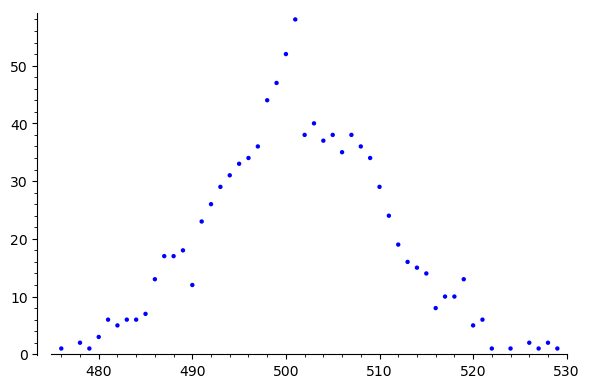

In [12]:
def polya_debil2(b, n, r, extracciones):
    propb=[(0,b/(b+n))]
    propn=[(0,n/(b+n))]
    for k in xsrange(extracciones):
        if random()<b/(b+n):
            n+=r
        else:
            b+=r
    return b

repeticiones=1000
extracciones=1000
r=1
dic=dict()
for _ in xsrange(repeticiones):
    nuevo=polya_debil2(1, 1, r, extracciones)
    if nuevo in dic:
        dic[nuevo]+=1
    else:
        dic[nuevo]=1

points(dic.items()) 

In [ ]:
#Parece que sale más o menos una campana

**e)** Considera otros juegos de valores, por ejemplo:

- 2 blancas iniciales, 1 negra inicial, 1 bola añadida en cada extracción
- 3 blancas iniciales, 1 negra inicial, 1 bola añadida en cada extracción
- 1 blanca inicial, 1 negra inicial, 5 bolas añadidas en cada extracción
- 2 blancas iniciales, 1 negra inicial, 5 bolas añadidas en cada extracción
- 3 blancas iniciales, 1 negra inicial, 5 bolas añadidas en cada extracción

Analiza lo que observas.

**SUGERENCIA**: Para no tener que teclear (o copiar) el código cada vez, puedes escribir una función que devuelva el plot para la urna fuerte y otra que devuelva el plot para la urna débil.

<p><span style="font-size: large;"><strong>Primero las urnas fuertes</strong></span></p>

In [18]:
def plot_fuerte(b, n, r, extracciones):
    repeticiones=1000
    dic=dict()
    for _ in xsrange(repeticiones):
        nuevo=polya_fuerte2(b, n, r, extracciones)
        if nuevo in dic:
            dic[nuevo]+=1
        else:
            dic[nuevo]=1 
                   
    return points(dic.items())



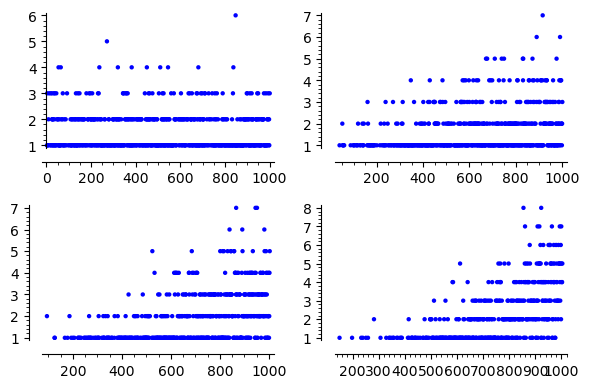

In [19]:
g1=plot_fuerte(1, 1, 1, 1000)
g2=plot_fuerte(2, 1, 1, 1000)
g3=plot_fuerte(3, 1, 1, 1000)
g4=plot_fuerte(4, 1, 1, 1000)

    
graphics_array(((g1,g2),(g3,g4)))

In [15]:
#Ahora que hubiera inicialmente más blancas favorece que terminen predominando
#Y cuanto más fuera el desequilibrio inicial, mayor es el predominio de las blancas

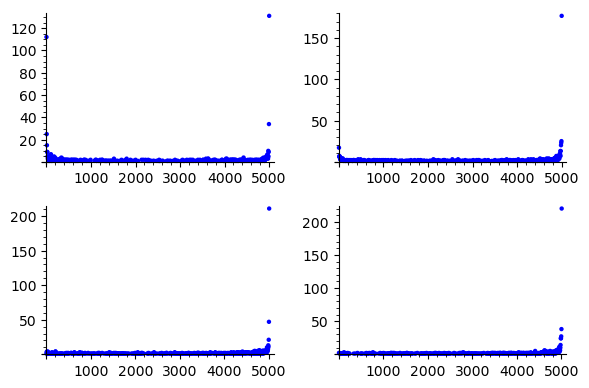

In [20]:
g1=plot_fuerte(1, 1, 5, 1000)
g2=plot_fuerte(2, 1, 5, 1000)
g3=plot_fuerte(3, 1, 5, 1000)
g4=plot_fuerte(4, 1, 5, 1000)

graphics_array(((g1,g2),(g3,g4)))

In [17]:
#Cuando se añaden muchas bolas se favorece el predominio de unas u otras. 

#Si inicialmente había las mismas de cada color se produce una simetría: lo habitual es que acabe habiendo predominio
#de bolas de un color, pero es indistinto de cuál de los dos colores

#Si inicialmente hay desequilibrio, el resultado ya no es simétrico: lo habitual es que acaben predominando 
#las que predominaban al principio


<p><span style="font-size: large;"><strong>Ahora las urnas débiles</strong></span></p>


In [21]:
def plot_debil(b, n, r, extracciones):
    repeticiones=1000
    dic=dict()
    for _ in xsrange(repeticiones):
        nuevo=polya_fuerte2(b, n, r, extracciones)
        if nuevo in dic:
            dic[nuevo]+=1
        else:
            dic[nuevo]=1 
                   
    return points(dic.items())



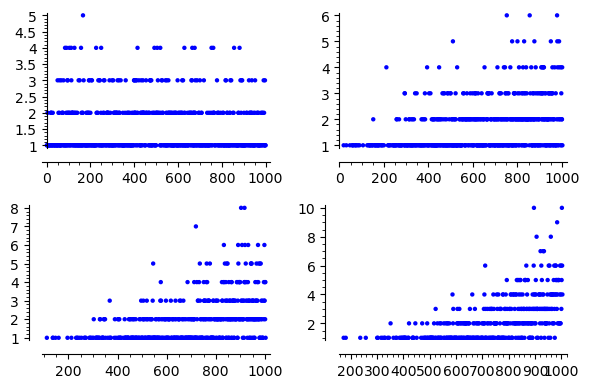

In [22]:
g1=plot_debil(1, 1, 1, 1000)
g2=plot_debil(2, 1, 1, 1000)
g3=plot_debil(3, 1, 1, 1000)
g4=plot_debil(4, 1, 1, 1000)

graphics_array(((g1,g2),(g3,g4)))

In [20]:
#Este proceso tiende al equilibrio, un poco escorado en función del desequilibrio inicial

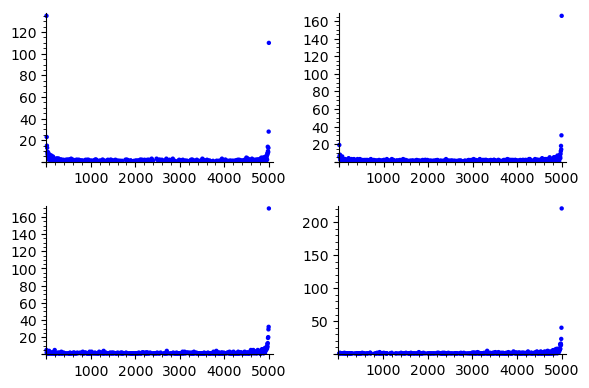

In [23]:
g1=plot_debil(1, 1, 5, 1000)
g2=plot_debil(2, 1, 5, 1000)
g3=plot_debil(3, 1, 5, 1000)
g4=plot_debil(4, 1, 5, 1000)

graphics_array(((g1,g2),(g3,g4)))

In [22]:
#El número de bolas que reemplazo tras cada extracción no parece jugar un papel muy relevante

## 2. La ruina del jugador ##

Vamos a estudiar otro problema clásico, conocido como <a href="https://en.wikipedia.org/wiki/Gambler%27s_ruin" target="_blank"> la ruina del jugador </a> (pincha para consultar información en la Wikipedia). Se trata de un jugador que apuesta dinero contra *la banca* a un juego en el que tiene probabilidad $p$ de ganar. Si gana el jugador, recupera su dinero y la banca le paga otro tanto. Si pierde el jugador, pierde el dinero apostado.

Supongamos que el jugador tiene un capital inicial de $n$ euros, que la apuesta en cada jugada es de 1 euro, y que la estrategia del jugador es seguir apostando hasta que se arruine o hasta que llegue a hacerse con $N$ euros. 

*Nota*: si lo piensas un poco, verás la relación que hay entre este problema y los paseos aleatorios unidimensionales que tratamos en clase.

**a)** Escribe una función de sage que dependa de $n$, de $N$ y de $p$, y que devuelva True si el jugador se arruina y False si el jugador no se arruina (es decir, si llega a $N$ euros)

In [24]:
def ruina(n,N,p):
    dinero=n
    while dinero>0 and dinero<N:
        if random()<p:
            dinero+=1
        else:
            dinero+=-1
    return dinero==0
    
    

**b)** Es un hecho conocido que en el caso de un *juego justo* (es decir, con $p=1/2$), la probabilidad de que el jugador se arruine vale $1-n/N$ (así que, por ejemplo, si el objetivo del jugador es duplicar su capital inicial, es decir si $N=2n$, la probabilidad de ruina es $1/2$). 

En este apartado vamos a comprobar experimentalmente que estas son efectivamente las probabilidades de arruinarse: tomando $N=50$, realiza $100$ simulaciones con cada uno de los capitales iniciales posibles $n=0,1, \ldots , N$ (aunque los casos $n=0$ y $n=N$ no requieren en realidad simulación: ¿por qué?), y cuenta la proporción $p_n$ de ruinas que se observa en ese número de repeticiones para cada $n$. Representa gráficamente los puntos $(n, p_n)$.

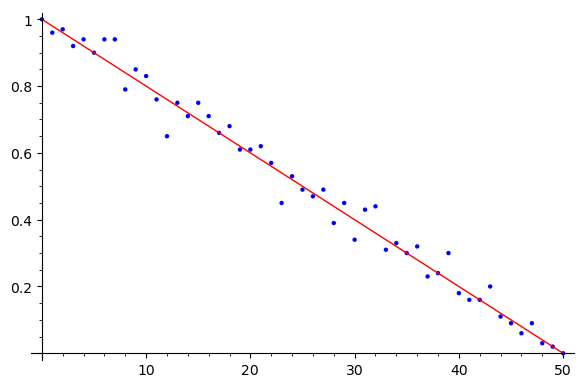

In [25]:
N=50
p=1/2
simulaciones=100
puntos=[]
for n in xsrange(N+1):
    exitos=0
    for _ in xsrange(simulaciones):
        exitos+=ruina(n,N,p)
    puntos.append((n,(exitos/simulaciones).n()))
    
points(puntos)+plot(1-x/N, x, 0, N, color='red')

**c)** Un ejemplo de *juego justo* es el de una "ruleta justa", que tendría 18 números negros y 18 números rojos. El jugador apuesta en cada jugada que va a salir un número rojo, y por tanto $p=1/2$. Sin embargo, las ruletas reales de los casinos no son ruletas justas: las europeas tienen una casilla, numerada como 0, que no es roja ni negra y que si sale hace ganar a la banca. Las americanas, además, tienen otra casilla, con las mismas características, numerada 00.

Analiza primero cuál es el valor de $p$ para una ruleta europea y para una americana. A continuación, repite para ambas el experimento del apartado anterior.

In [26]:
peur=(18/37).n()
pame=(18/38).n()
peur, pame

(0.486486486486487, 0.473684210526316)

In [26]:
#No parecen taaaan lejos del caso de "juego justo". Sin embargo, el cambio va a ser drástico.

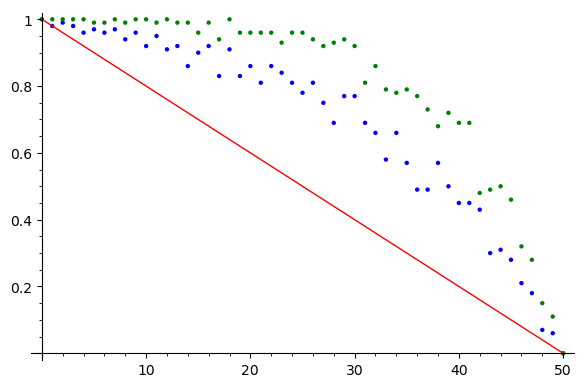

In [27]:
N=50
simulaciones=100
puntoseur=[]
for n in xsrange(N+1):
    exitos=0
    for _ in xsrange(simulaciones):
        exitos+=ruina(n,N,peur)
    puntoseur.append((n,(exitos/simulaciones).n()))
    
puntosame=[]
for n in xsrange(N+1):
    exitos=0
    for _ in xsrange(simulaciones):
        exitos+=ruina(n,N,pame)
    puntosame.append((n,(exitos/simulaciones).n()))    
    
points(puntoseur)+points(puntosame, color='green')+plot(1-x/N, x, 0, N, color='red') #lo último por comparar con el "caso justo".

In [28]:
#Tremendo! Recuerdas que en el caso justo, la probabilidad de ruina en el caso N=2n era 1/2, no? 
#Veamos el mismo dato para ruletas reales:
puntoseur[25], puntosame[25]

((25, 0.780000000000000), (25, 0.960000000000000))

**d)** Vamos a cambiar un poco la estrategia del jugador, que ahora en vez de jugar hasta alcanzar $N$ euros o arruinarse, lo que decide hacer es jugar un número máximo $M$ de veces (decimos *máximo* porque podría arruinarse antes y no llegar a jugar tantas veces). 

Escribe un programa que dependa de la probabilidad $p$ de ganar cada partida, del capital inicial $n$ y del número máximo $M$ de jugadas, que devuelva el capital que tenemos al retirarnos.

In [29]:
def capital_final(p, n, M):
    pasos=0
    capital=n
    while capital>0 and pasos<M:
        if random()<p:
            capital+=1
        else:
            capital+=-1
        pasos+=1
    return capital

**e)** Observa que si usamos esta estrategia con un capital inicial mayor que el máximo de jugadas estamos haciendo un paseo aleatorio, empezando en una posición igual al capital inicial, pero si jugamos por ejemplo $M=100$ veces empezando con 10&euro;, hay riesgo de arruinarse y la situación cambia. 

Utiliza la función anterior para simular 1000 veces sobre una ruleta justa $(p=1/2)$ la situación que acabamos de describir ($M=100$, $n=10$) y dibuja los puntos que representan las frecuencias con las que se dan las distintas ganancias en las 1000 repeticiones. ¿Cuál sería la ganancia media en los 1000 intentos? ¿Cuál el número de veces que nos arruinamos?

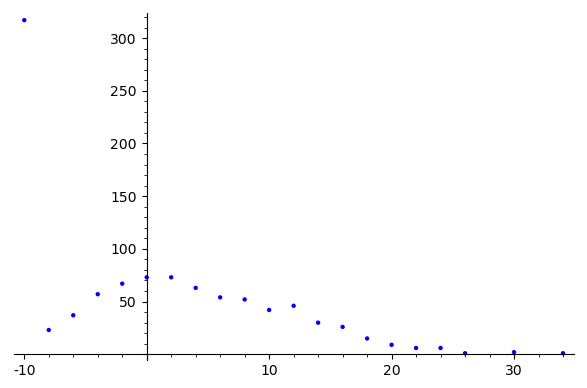

In [30]:
p=1/2
n=10
M=100
repeticiones=1000
dic=dict()
for _ in xsrange(repeticiones):
    nuevo= capital_final(p,n,M)-n
    if nuevo in dic:
        dic[nuevo]+=1
    else:
        dic[nuevo]=1
points(dic.items())

In [31]:
#Ganancia media
(sum([x*dic[x] for x in dic])/repeticiones).n()

-0.146000000000000

In [32]:
#Número de veces que nos arruinamos
dic[-10]

317

**f)** Repite los cálculos del apartado anterior si se juega con una ruleta real (europea o americana).

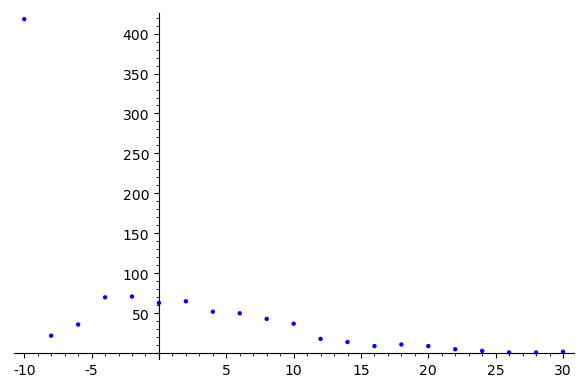

La ganancia media es -2.41200000000000
El número de veces que nos arruinamos es 418


In [37]:
#con ruleta europea
peur=(18/37)
n=10
M=100
repeticiones=1000
dic=dict()
for _ in xsrange(repeticiones):
    nuevo= capital_final(peur,n,M)-n
    if nuevo in dic:
        dic[nuevo]+=1
    else:
        dic[nuevo]=1
show(points(dic.items()))
gmedia=(sum([x*dic[x] for x in dic])/repeticiones).n()
ruinas=dic[-10]
print('La ganancia media es %s'%(gmedia))
print('El número de veces que nos arruinamos es %s'%(ruinas))

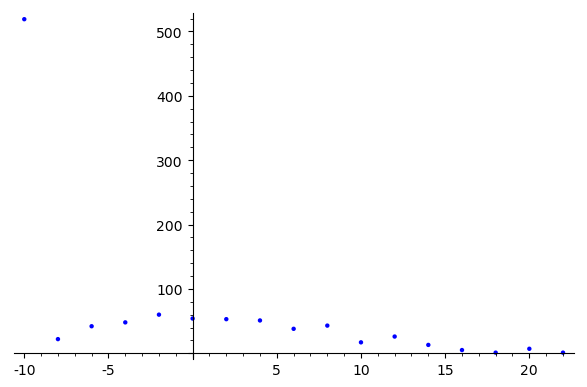

La ganancia media es -4.12400000000000
El número de veces que nos arruinamos es 519


In [38]:
#con ruleta americana
pame=(18/38)
n=10
M=100
repeticiones=1000
dic=dict()
for _ in xsrange(repeticiones):
    nuevo= capital_final(pame,n,M)-n
    if nuevo in dic:
        dic[nuevo]+=1
    else:
        dic[nuevo]=1
show(points(dic.items()))
gmedia=(sum([x*dic[x] for x in dic])/repeticiones).n()
ruinas=dic[-10]
print('La ganancia media es %s'%(gmedia))
print('El número de veces que nos arruinamos es %s'%(ruinas))

**g)** Vamos a experimentar con otra estrategia de juego.

Empezamos con un capital inicial $n$. En la primera ronda apostamos 1&euro;. Si ganamos nos retiramos, pero si perdemos seguimos jugando y doblamos la apuesta: apostamos 2&euro;. Si perdemos, seguimos doblando la apuesta (4&euro;, 8&euro;, ...) hasta que ganamos una vez, momento en que nos retiramos. Por supuesto, también nos retiramos (forzados) si nos arruinamos, que ahora significa que nos queda menos dinero del que nos tocaría apostar.

**Observa** que, si ganamos en la jugada $m$, el capital invertido será $1+2+2^2+\dots+2^{m-1}=2^m-1$, y lo que nos pagarían sería $2\cdot 2^{m-1}=2^m$. Por tanto, esta estrategia sólo produce dos resultados: arruinarnos o ganar 1&euro;.

**Observa** también que si tuviésemos capital infinito no nos arruinaríamos, y "casi seguramente" ganaríamos 1&euro;. La única posibilidad de no ganar sería que nunca ganásemos una partida, lo que es posible pero (salvo que la probabilidad $p$ de ganar cada partida fuese 0) sucede con probabilidad 0 (más adelante aprenderás que se dice que ganamos 1&euro; "casi seguramente").

Así, lo que nos interesa es considerar un capital inicial $n$ y ver cuál es la probabilidad de ganar 1&euro; (la opción alternativa es, ahora literalmente, arruinarnos). Por ejemplo, para $n=1$ (tenemos 1&euro; y, o ganamos a la primera o dejamos de jugar), la probabilidad de ganar 1&euro; coincide exactamente con la de ganar la primera partida.

Escribe un programa que, dados la probabilidad $p$ de ganar cada partida y el capital inicial $n$, simule esta  manera de jugar y devuelva True si el jugador gana (1&euro;) y False si se arruina.

In [39]:
def juego2(p, n):
    jugada=0
    capital=n
    apuesta=0
    ganada=0
    while capital>apuesta and ganada==0:
        apuesta=2^jugada
        if random()<p:
            capital+=apuesta
            ganada=1
        else:
            capital+=-apuesta
        jugada+=1
    return ganada==1

**h)** Utiliza el programa anterior para escribir otro que, dadas la probabilidad $p$, el capital inicial $n$, y un número de repeticiones de esta segunda forma de jugar, calcule la proporción de veces que ganamos. 

In [40]:
def prop_ganadas(p,n, rep):
    exitos=0
    for _ in xsrange(rep):
        exitos+=juego2(p,n)
    return (exitos/rep).n()

**i)** Dibuja, sobre unos mismos ejes y con colores distintos, tres gráficas que representen la proporción de veces que ganamos en 1000 repeticiones para capitales iniciales $n=2^k-1$ con $k\in\{1,\dots,15\}$: una gráfica jugando con una ruleta "justa", otra con una ruleta europea y otra con una ruleta americana. En el eje horizontal debes representar $k$, no $n$.

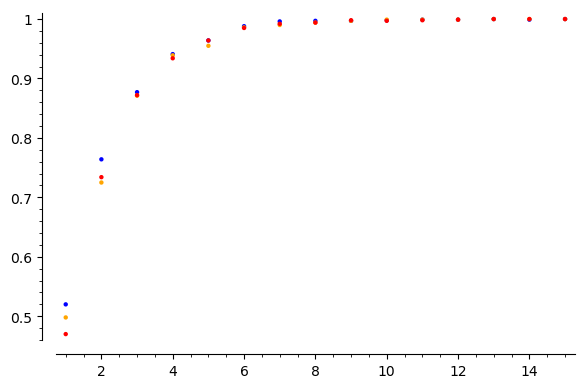

In [41]:
p=1/2
peur=(18/37)
pame=(18/38)
rep=1000
puntos=[]
puntoseur=[]
puntosame=[]
for k in [1..15]:
    n=2^k-1
    puntos.append((k,prop_ganadas(p, n, rep)))
    puntoseur.append((k,prop_ganadas(peur, n, rep)))
    puntosame.append((k,prop_ganadas(pame, n, rep)))
points(puntos)+points(puntoseur, color='orange')+ points(puntosame, color='red')